In [1]:

# 1: Data Preparation


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# load dataset
customer_df = pd.read_csv('q2_customers.csv')

print("First 5 rows:")
print(customer_df.head())

# scaling features
scaler_model = StandardScaler()
scaled_features = scaler_model.fit_transform(customer_df)

print("\nScaling completed")

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Scaling completed


## Data Preparation

Before using K-Means, we need to scale the data.

K-Means groups customers based on distance. If one feature like annual_spend has much bigger values than something like age, the model will focus more on spending and ignore other features.

To avoid this, we scale all features so they are on a similar range. This way, every feature gets equal importance when forming clusters.

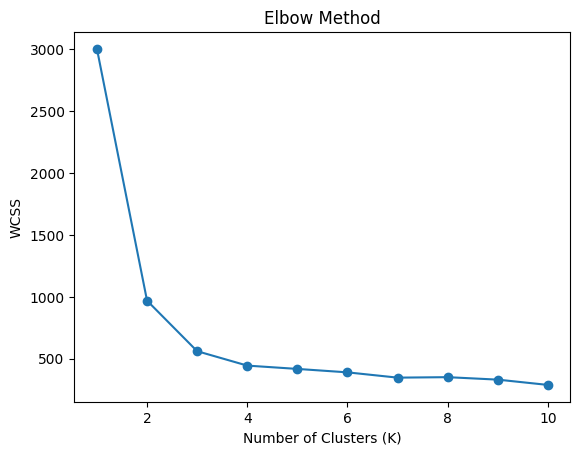

In [2]:
# 2:  Choosing K — Elbow Method


from sklearn.cluster import KMeans

wcss_values = []

for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_model.fit(scaled_features)
    wcss_values.append(kmeans_model.inertia_)

# plot
plt.plot(range(1, 11), wcss_values, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## Choosing the Optimal Number of Clusters

From the elbow plot, we can see that the WCSS value drops sharply from K = 1 to K = 3 and after that, the decrease becomes much slower.

For example:
- At K = 1, WCSS is very high (around 3000)
- At K = 2, it drops significantly (around 950)
- At K = 3, it drops further (around 550)
- After K = 3, the improvement becomes smaller and more gradual

This point where the curve starts to flatten is called the "elbow point".

So, the optimal number of clusters is K = 3, because adding more clusters after this does not significantly improve the model.

In [3]:
# 3: K-Means Clustering


# choose K (replace this)
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(scaled_features)

# add cluster column
customer_df['cluster'] = cluster_labels

print("\nClustered Data:")
print(customer_df.head())

# centroids
centroid_df = pd.DataFrame(
    scaler_model.inverse_transform(kmeans_final.cluster_centers_),
    columns=customer_df.columns[:-1]
)

print("\nCluster Centroids:")
print(centroid_df)


Clustered Data:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_l

## Cluster Interpretation

Based on the cluster centroids, we can understand the different types of customers:

- Cluster 0:
  These customers are younger with average age around 25 with low annual spend around 14,800.
  They visit the store frequently around 14 visits per month but have a small basket size.
  This means they are regular visitors but spend less each time. These can be seen as frequent low-value customers.

- Cluster 1:
  These customers are older, average age around 57 and have very high annual spend around 89,000.
  However, they visit very rarely around 2–3 times per month but have a very large basket size.
  This means they make fewer visits but spend a lot in one go. These are high-value premium customers.

- Cluster 2:
  These customers are middle-aged, around 40 years old with moderate spending around 43,000.
  They visit occasionally around 8 times per month and have a medium basket size.
  These are moderate-value customers with balanced behavior.

## Conclusion

The clustering clearly separates customers into three groups:
- Low spend frequent shoppers  
- High spend occasional shoppers  
- Moderate customers  

This can help businesses target each group differently with personalized marketing strategies.

In [4]:
# 4: PCA


from sklearn.decomposition import PCA

pca_model = PCA(n_components=2)

pca_result = pca_model.fit_transform(scaled_features)

print("Explained Variance Ratio:")
print(pca_model.explained_variance_ratio_)

# loadings
loading_df = pd.DataFrame(
    pca_model.components_,
    columns=customer_df.columns[:-1],
    index=['PC1', 'PC2']
)

print("\nFeature Loadings:")
print(loading_df)

Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


### PCA Interpretation

PCA reduces the dataset into two main components while keeping most of the important information.

From the explained variance ratio:
- PC1 explains about 83.56% of the total variance
- PC2 explains about 5.57%

This means that PC1 captures most of the important patterns in the data, while PC2 adds a smaller amount of additional information.

Looking at the feature loadings:

- PC1 has strong contributions from features like annual_spend  of 0.42 and basket_size of 0.41, num_categories_purchased of 0.41, and age, 0.41.  
  This suggests that PC1 mainly represents overall customer value and spending behavior.

- PC2 is heavily influenced by days_since_last_visit, 0.91.  
  This means PC2 captures how recently customers visited the store.

## Conclusion

- PC1 represents how valuable or active a customer is in terms of spending and purchases.
- PC2 represents customer recency (how recently they visited).

These two components help simplify the data while still capturing the most important patterns.

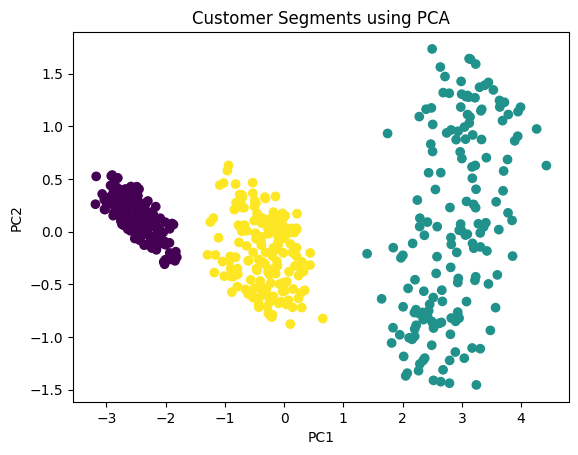

In [5]:
# 5: Visualization


plt.scatter(pca_result[:, 0], pca_result[:, 1], c=customer_df['cluster'])

plt.title("Customer Segments using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## Cluster Visualization

The scatter plot shows the customer segments using the two principal components (PC1 and PC2).

Each color represents a different cluster, and we can clearly see three separate groups in the plot.

- One cluster is on the left side (low PC1 values), which represents lower-value or lower-spending customers.
- One cluster is in the middle, showing moderate customers with average behavior.
- One cluster is on the right side (high PC1 values), which represents high-value customers with higher spending and activity.

The clusters are well separated, which means the K-Means model has done a good job grouping similar customers together.

## Conclusion

The visualization makes it easy to understand how customers are divided into different segments based on their behavior, which can help businesses target each group more effectively.